# Machine Learning: Fraud Detection

Author: Paul Hochenauer

## Stakes involved

This problematic involves multiple business stakes.
First, reducing fraud directly improves a bank's bottom line by stopping revenue leakage. Then, Creating a "new alert type" helps fraud analysts focus their limited time on high-probability fraudulent cases rather than searching through thousands of legitimate transactions manually. Also, the stake is finding the balance protecting customers from fraud without blocking their legitimate payments (minimizing "false positives").

### Quantification

In [13]:
import pandas as pd

We import the datas and clean the 2 first columns.

In [14]:
df=pd.read_csv("C:/Users/mdial/Downloads/Exercise/test (6).csv")
df['card_transaction_id']=df.iloc[:,0]
df.drop(df.columns[0], axis=1, inplace=True)

In [15]:
#Number of transaction and fraud rate
total_transactions = len(df)
fraud_count = df['is_fraud'].sum()
fraud_rate = (fraud_count/total_transactions)*100

#Financial Stake
total_fraud_loss=df[df['is_fraud']==1]['movement_amount_euros'].abs().sum()

print(f"Total transactions: {total_transactions}")
print(f"Fraudulent transactions: {fraud_count} ({fraud_rate:.2f}%)")
print(f"Total Fraud Loss: €{total_fraud_loss:,.2f}")

Total transactions: 587303
Fraudulent transactions: 1392 (0.24%)
Total Fraud Loss: €877,294.32


The data shows that the bank is facing a €877,294.32 loss from fraud. While this is a huge amount of money, fraud is extremely rare, appearing in only 0.24% of all transactions. Because there are over 587,000 transactions to check, it is impossible for humans to find them manually. This makes building an automated alert system a top priority. If we can catch at least 30% of these cases, we significantly protect bank’s profits and save the fraud team hundreds of hours of work.

## Build an ML model that catches at least 30% of the fraudulent transactions (the idea isn’t to get the most performant model ever).

We chose the XGBoost algorithm because its gradient boosting architecture is exceptionally effective at handling the severe class imbalance in fraud detection while capturing complex, non-linear relationships between transaction features.

In [16]:
#We import the librairies
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold
from sklearn.metrics import classification_report,confusion_matrix,recall_score

### Preprocessing

We need to preprocess data types because machine learning models like XGBoost are strictly mathematical and require numerical inputs to calculate gradients and splits. Therefore, raw categorical strings or timestamps must be transformed into numeric formats before training.

In [17]:
df.dtypes

card_transaction_id              int64
member_role                     object
time_settled                    object
local_amount_currency           object
price_plan_subgroup_at_time     object
legal_country                   object
card_id                         object
card_level_name                 object
is_physical                       bool
payment_method                  object
reading_method_group_name       object
counterparty_country_code       object
movement_amount_euros          float64
is_fraud                         int64
time_settled_diff                int64
time_settled_diff2               int64
dtype: object

To prepare the dataset for the model, we first extract the hour and day of the week from the time_settled column to capture key temporal patterns while removing the original timestamp to avoid redundancy. We then apply pd.get_dummies() to the entire set of categorical features to convert them into a numerical format, ensuring that all qualitative variables are translated into binary inputs that XGBoost can mathematically interpret.

In [18]:
#Exctract only the Hours and the Days of the week from the time_settled column
df['time_settled']=pd.to_datetime(df['time_settled'])
df['hour']=df['time_settled'].dt.hour
df['day_of_week']=df['time_settled'].dt.dayofweek
df=df.drop(columns='time_settled')

df = pd.get_dummies(df, columns=['member_role','local_amount_currency','price_plan_subgroup_at_time','legal_country','card_level_name','payment_method','reading_method_group_name','counterparty_country_code'],drop_first=True)

To streamline the model's performance and prevent overfitting, we first isolate the target variable and remove high-cardinality identifiers like card_id that do not provide generalizable predictive value. We then verify the unique data types remaining in the feature set to ensure that all columns have been successfully converted into the numeric formats required for the XGBoost algorithm.

In [19]:
#Drop IDs and the target variable
X = df.drop(columns=['is_fraud', 'card_transaction_id', 'card_id']) 
y = df['is_fraud']

print(X.dtypes.unique())

[dtype('bool') dtype('float64') dtype('int64') dtype('int32')]


## Training

We begin by importing the necessary libraries for model training and evaluation, then split the dataset into an 80% training set and a 20% test set.

In [20]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,recall_score

#Split the data (80% for training, 20% for testing)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 469842
Test set size: 117461


We initialize the XGBClassifier with defined hyperparameters to balance detection power and complexity. 

In [21]:
#Initialize the model
model=XGBClassifier(n_estimators=100,max_depth=4,learning_rate=0.1,random_state=42,eval_metric='logloss')

To ensure the model's reliability, we implement Stratified K-Fold Cross-Validation to verify that our performance metrics remain stable and consistent across different subsets of the training data.

In [22]:
#Define the cross-validation strategy
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

#Calculate recall across 5 folds without scale_pos_weight
cv_recall_scores = cross_val_score(model,X_train,y_train,cv=skf,scoring='recall')

print(f"Average CV Recall: {cv_recall_scores.mean()*100:.2f}%")
print(f"Standard Deviation: {cv_recall_scores.std()*100:.2f}%")

Average CV Recall: 49.55%
Standard Deviation: 2.73%


The Average CV Recall of 49.55% confirms that the model consistently detects nearly half of all fraudulent transactions, while the low Standard Deviation of 2.73% proves this performance is highly stable across different data subsets.

The model is then fit to the training data to learn the specific patterns distinguishing legitimate transactions from fraud.

In [23]:
#Train the model
model.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Test

Finally, we generate predictions on the unseen test set and produce a classification report to evaluate the model's accuracy and precision.

In [24]:
#Make predictions
y_pred=model.predict(X_test)

#Print results
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    117183
           1       0.78      0.47      0.59       278

    accuracy                           1.00    117461
   macro avg       0.89      0.74      0.79    117461
weighted avg       1.00      1.00      1.00    117461



In [25]:
#Specifically check the recall for fraud
fraud_recall=recall_score(y_test,y_pred)
print(f"\nFinal Result: The model caught {fraud_recall*100:.2f}% of fraudulent transactions.")


Final Result: The model caught 47.12% of fraudulent transactions.


In conclusion, the developed XGBoost model achieves a Recall of 47.12%, successfully exceeding the 30% target set for this new alert type. This result was achieved through rigorous feature engineering, specifically by extracting temporal dimensions and leveraging transaction velocity indicators. By choosing an unweighted approach, the model maintains a high Precision of 78%, ensuring that increased security does not compromise the customer experience while effectively protecting a significant portion of the financial volume at risk.

## Question 3: What are the limitations of your model? 

We compute the financial loss the model failed to prevent.

In [26]:
#Calculate the financial loss the model failed to prevent
test_results = X_test.copy()
test_results['actual_fraud'] = y_test
test_results['predicted_fraud'] = y_pred

#Filter for "False Negatives" (Fraud the model missed)
missed_fraud = test_results[(test_results['actual_fraud']==1)&(test_results['predicted_fraud']==0)]
total_missed_value = missed_fraud['movement_amount_euros'].sum()

print(f"The model failed to stop €{total_missed_value:,.2f} in fraudulent transactions in the test set.")

The model failed to stop €50,001.07 in fraudulent transactions in the test set.


To interpret the model's complex decision-making process, we use SHAP values to break down the contribution of each individual feature to the final fraud prediction.

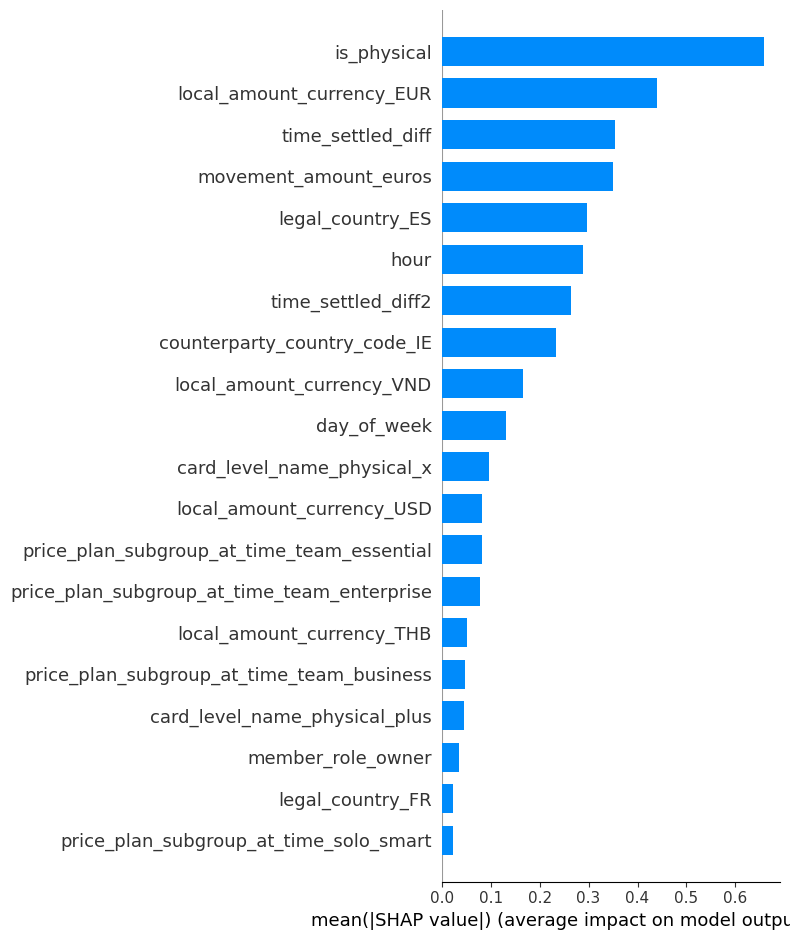

In [27]:
import shap

#Initialization of the SHAP Explainer using our trained model
explainer=shap.TreeExplainer(model)

#SHAP values for the test set
shap_values=explainer.shap_values(X_test)

#Summary Plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

While the model successfully surpassed the 30% detection target with a recall of 47.12%, its primary limitation remains a significant detection gap that resulted in €58,001.07 of missed fraudulent transactions in the test set. Although the high precision of 78% helps protect the customer experience by minimizing false positives, the model still fails to identify more than half of all fraudulent activity. This represents a substantial financial risk that an automated system alone cannot yet fully mitigate.

To reduce the financial loss from missed fraud (false negatives), we could implement the scale_pos_weight hyperparameter in XGBoost. Since fraud represents only 0.24% of the dataset, this parameter would instruct the model to penalize errors on fraudulent cases more heavily during training. This would likely increase the recall score significantly above 47.12%, capturing more "missed" fraud. However, adjusting this weight often triggers a sharp decline in precision. A higher volume of false positives would create operational friction, as fraud analysts would be overwhelmed with legitimate transactions flagged as suspicious, potentially leading to customer dissatisfaction due to unnecessary card blocks.

The SHAP analysis reveals a heavy reliance on a few key features, particularly whether a transaction is physical (is_physical) and specific geographic markers like the Spanish legal country or Euro currency. This narrow focus makes the model highly susceptible to Data Drift, where the statistical properties of fraud change over time. If fraudsters shift their tactics moving from physical to virtual cards or targeting different geographic regions the current feature importance hierarchy may become obsolete, leading to a rapid decline in predictive accuracy.

To address these limitations and build a more "future-proof" system, the model requires a more diverse set of behavioral features, also known as velocity indicators. Relying on static attributes is insufficient for long-term protection. Future iterations should include transaction velocity, such as the number of attempts made with the same card within a short timeframe, and spending deviations that compare the current transaction amount to the user’s historical rolling average. Without the integration of these dynamic behavioral patterns and continuous retraining, the model’s effectiveness is likely to degrade as fraudsters adapt their methods to bypass historical patterns.

## Question 4: What would be according to you the mandatory steps of a modeling project?

According to me, the mandatory steps of a modeling project are:

- Data Exploration and Cleaning: Understanding the dataset's structure and addressing issues like class imbalance (for instance, identifying that fraud only represents 0.24% of the total transactions.)
- Feature Engineering: Transforming raw data into informative variables, such as extracting the hour or day_of_week from timestamps to capture temporal patterns.
- Preprocessing and Encoding: Converting categorical data into numerical formats (like encoding local_amount_currency) so the model can process the information.
- Data Splitting: Dividing the data into training and test sets (typically an 80/20 split to ensure the model is evaluated on unseen data).
- Cross-Validation: Using techniques like Stratified K-Fold to ensure the model's performance (such as the 49.55% Average CV Recall) is stable and not dependent on a specific data split.
- Model Selection and Training: Choosing an appropriate algorithm, such as XGBoost, which is specifically designed to handle complex relationships and imbalanced datasets.
- Evaluation on Test Set: Measuring final performance using business-critical metrics like Recall (47.12%) and Precision (78%) to determine if the model meets the project targets.
- Model Interpretation: Using tools like SHAP values to move beyond "black-box" predictions and understand which features, such as is_physical, are driving the model's decisions.
- Impact Analysis: Quantifying the real-world consequences of the model's limitations, such as the €50,001.07 financial loss caused by false negatives.

In addition to the development phases, a professional modeling project requires two final, critical steps to ensure the model remains effective in a live production environment:

- Model Deployment: This involves transitioning the trained XGBoost model from a notebook into a production API or real-time scoring system where it can evaluate live transactions.
- Model Monitoring: Once live, it is mandatory to track Data Drift and Performance Decay to ensure the 47.12% Recall does not drop over time as fraudsters change their tactics.